# Tarefa 3 — Resolvendo Equações Diferenciais com PINNs (PyTorch)

## Problema de Poisson 1D com Redes Neurais Informadas por Física

**Disciplina:** DEC101455 — Tópicos em Modelagem Computacional  
**Programa:** Pós-graduação em Modelagem Computacional — UESC  
**Professor:** Prof. Dany S. Dominguez

---

### Descrição do Problema

Resolver o problema de Poisson unidimensional usando PINNs:

$$\Delta u = u_{xx} = \frac{d^2u}{dx^2} = f(x)$$

**Problema 1:** $f(x) = -\pi^2 \sin(\pi x)$, com $u(-1) = 0$ e $u(1) = 0$

**Problema 2 (modificação):** $f(x) = \pi^2 \cos(\pi x)$, com $u(-1) = 0$ e $u(1) = 0$

---

### O que é uma PINN?

Uma **Physics-Informed Neural Network (PINN)** é uma rede neural que incorpora as leis da física (equações diferenciais) diretamente na função de perda durante o treinamento. Em vez de depender apenas de dados, a PINN aprende a solução respeitando a equação diferencial governante e as condições de contorno.

A função de perda total é composta por:

$$\mathcal{L}_{total} = \mathcal{L}_{PDE} + \mathcal{L}_{BC}$$

onde:
- $\mathcal{L}_{PDE}$: penaliza o resíduo da equação diferencial nos pontos internos do domínio
- $\mathcal{L}_{BC}$: penaliza a violação das condições de contorno


## 1. Importação das Bibliotecas

Importamos as bibliotecas necessárias:
- **PyTorch**: framework de deep learning para construir e treinar a rede neural
- **NumPy**: computação numérica
- **Matplotlib**: visualização dos resultados


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Configurações gerais
torch.manual_seed(42)           # Semente para reprodutibilidade
np.random.seed(42)

# Verificar se GPU está disponível
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo utilizado: {device}")


Dispositivo utilizado: cuda


In [1]:
import pyDOE

---

# PARTE 1 — Problema Original

$$\frac{d^2u}{dx^2} = -\pi^2 \sin(\pi x), \quad u(-1) = 0, \quad u(1) = 0$$

## 2. Solução Analítica

Para encontrar a solução analítica, resolvemos a EDO:

$$u''(x) = -\pi^2 \sin(\pi x)$$

Integrando uma vez:

$$u'(x) = \pi \cos(\pi x) + C_1$$

Integrando novamente:

$$u(x) = \sin(\pi x) + C_1 x + C_2$$

Aplicando as condições de contorno:
- $u(-1) = \sin(-\pi) + C_1(-1) + C_2 = 0 - C_1 + C_2 = 0$
- $u(1) = \sin(\pi) + C_1(1) + C_2 = 0 + C_1 + C_2 = 0$

Do sistema: $C_1 = 0$ e $C_2 = 0$.

**Solução analítica:** $u(x) = \sin(\pi x)$


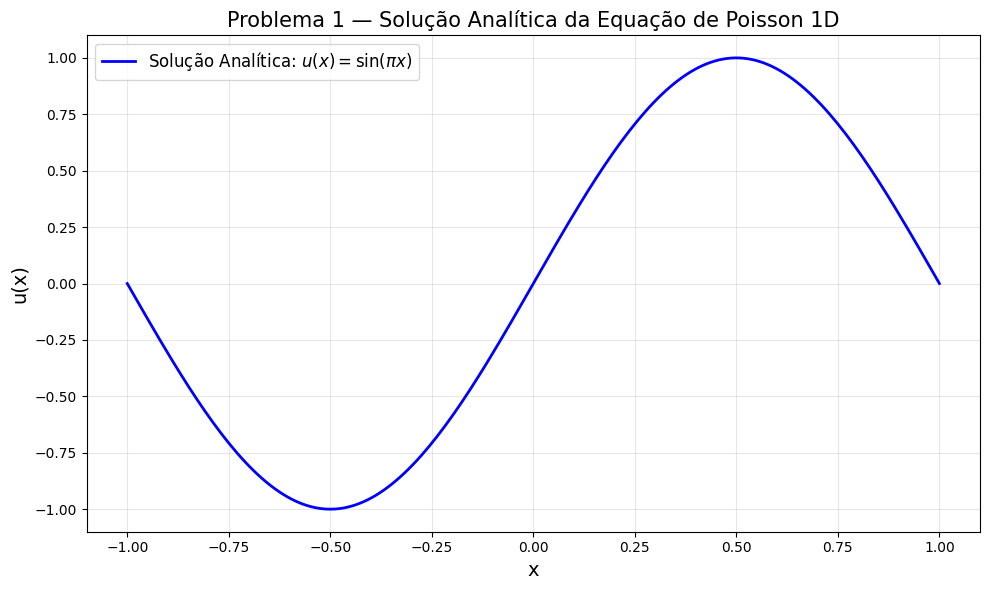

In [2]:
# ============================================================
# 2. Solução Analítica — Problema 1
# ============================================================

# Domínio: x ∈ [-1, 1]
x_analitico = np.linspace(-1, 1, 200)
u_analitico = np.sin(np.pi * x_analitico)

# Plotar a solução analítica
plt.figure(figsize=(10, 6))
plt.plot(x_analitico, u_analitico, 'b-', linewidth=2, label='Solução Analítica: $u(x) = \sin(\pi x)$')
plt.xlabel('x', fontsize=14)
plt.ylabel('u(x)', fontsize=14)
plt.title('Problema 1 — Solução Analítica da Equação de Poisson 1D', fontsize=15)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Construção da Rede Neural (FCN)

Construímos uma **Fully Connected Network (FCN)** — rede totalmente conectada — que recebe $x$ como entrada e produz $\hat{u}(x)$ como saída.

### Arquitetura:
- **Entrada:** 1 neurônio (valor de $x$)
- **Camadas ocultas:** 3 camadas com 32 neurônios cada
- **Função de ativação:** $\tanh$ (diferenciável em todas as ordens, essencial para PINNs)
- **Saída:** 1 neurônio (valor predito de $u$)

A escolha da $\tanh$ como ativação é importante porque PINNs precisam calcular derivadas da saída da rede em relação à entrada. A $\tanh$ é infinitamente diferenciável, ao contrário da ReLU que tem derivada segunda nula.


In [3]:
# ============================================================
# 3. Definição da Rede Neural FCN
# ============================================================

class PINN(nn.Module):
    """
    Rede Neural Informada por Física (PINN) para resolver EDPs.
    
    Arquitetura: FCN (Fully Connected Network)
    - 1 entrada (x)
    - 3 camadas ocultas com 32 neurônios cada
    - Ativação: tanh
    - 1 saída (u)
    """
    
    def __init__(self, hidden_size=32, num_hidden_layers=3):
        super(PINN, self).__init__()
        
        # Construir as camadas dinamicamente
        layers = []
        
        # Camada de entrada: 1 -> hidden_size
        layers.append(nn.Linear(1, hidden_size))
        layers.append(nn.Tanh())
        
        # Camadas ocultas: hidden_size -> hidden_size
        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.Tanh())
        
        # Camada de saída: hidden_size -> 1
        layers.append(nn.Linear(hidden_size, 1))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        """
        Forward pass: recebe x e retorna u(x) predito.
        
        Parâmetros:
            x: tensor de forma (N, 1)
        Retorna:
            u: tensor de forma (N, 1) — predição da solução
        """
        return self.network(x)

# Instanciar o modelo
model_1 = PINN(hidden_size=32, num_hidden_layers=3).to(device)

# Exibir a arquitetura
print("Arquitetura da PINN:")
print(model_1)
print(f"\nNúmero total de parâmetros: {sum(p.numel() for p in model_1.parameters()):,}")


Arquitetura da PINN:
PINN(
  (network): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

Número total de parâmetros: 2,209


## 4. Definição das Funções de Perda

A PINN usa o **autograd** do PyTorch para calcular as derivadas da saída da rede em relação à entrada. Isso permite calcular $u_{xx}$ automaticamente.

### Perda da EDP (Resíduo da equação):

$$\mathcal{L}_{PDE} = \frac{1}{N} \sum_{i=1}^{N} \left( \frac{d^2 \hat{u}}{dx^2}\bigg|_{x_i} - f(x_i) \right)^2$$

onde $f(x) = -\pi^2 \sin(\pi x)$ e os $x_i$ são pontos de colocação no interior do domínio.

### Perda das Condições de Contorno:

$$\mathcal{L}_{BC} = \left( \hat{u}(-1) - 0 \right)^2 + \left( \hat{u}(1) - 0 \right)^2$$

### Perda Total:

$$\mathcal{L}_{total} = \mathcal{L}_{PDE} + \lambda \cdot \mathcal{L}_{BC}$$

O fator $\lambda$ (peso) dá mais importância às condições de contorno para garantir que sejam satisfeitas.


In [4]:
# ============================================================
# 4. Funções de Perda — Problema 1
# ============================================================

def compute_derivatives(model, x):
    """
    Calcula a segunda derivada de u em relação a x usando autograd.
    
    O PyTorch calcula derivadas automaticamente através do grafo computacional.
    Precisamos de create_graph=True para permitir derivadas de ordem superior.
    
    Parâmetros:
        model: a rede neural PINN
        x: tensor de entrada com requires_grad=True
    
    Retorna:
        u: predição da rede
        u_xx: segunda derivada d²u/dx²
    """
    # Forward pass
    u = model(x)
    
    # Primeira derivada: du/dx
    u_x = torch.autograd.grad(
        outputs=u,              # Função da qual derivar
        inputs=x,               # Variável em relação à qual derivar
        grad_outputs=torch.ones_like(u),  # Vetor de pesos (para Jacobiano)
        create_graph=True,      # Manter grafo para derivada segunda
        retain_graph=True       # Não destruir o grafo
    )[0]
    
    # Segunda derivada: d²u/dx²
    u_xx = torch.autograd.grad(
        outputs=u_x,
        inputs=x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
        retain_graph=True
    )[0]
    
    return u, u_xx


def loss_pde_prob1(model, x_interior):
    """
    Calcula a perda do resíduo da EDP para o Problema 1.
    
    Resíduo: u_xx - f(x) = u_xx - (-π² sin(πx)) = u_xx + π² sin(πx)
    
    Queremos que o resíduo seja zero em todos os pontos interiores.
    """
    u, u_xx = compute_derivatives(model, x_interior)
    
    # f(x) = -π² sin(πx)
    f_x = -np.pi**2 * torch.sin(np.pi * x_interior)
    
    # Resíduo: u_xx - f(x) deve ser zero
    residuo = u_xx - f_x
    
    return torch.mean(residuo**2)


def loss_bc(model, x_bc, u_bc):
    """
    Calcula a perda das condições de contorno.
    
    Compara a predição da rede nos pontos de contorno com os valores prescritos.
    
    Parâmetros:
        model: a rede PINN
        x_bc: posições dos contornos (x=-1 e x=1)
        u_bc: valores prescritos (u=0 em ambos)
    """
    u_pred = model(x_bc)
    return torch.mean((u_pred - u_bc)**2)


def loss_total_prob1(model, x_interior, x_bc, u_bc, lambda_bc=10.0):
    """
    Perda total = Perda_PDE + λ * Perda_BC
    
    O fator λ=10 dá mais peso às condições de contorno para
    garantir que a solução respeite os valores nos extremos do domínio.
    """
    l_pde = loss_pde_prob1(model, x_interior)
    l_bc = loss_bc(model, x_bc, u_bc)
    return l_pde + lambda_bc * l_bc, l_pde, l_bc

print("Funções de perda definidas com sucesso!")


Funções de perda definidas com sucesso!


## 5. Construção do Conjunto de Dados de Treino

Para o treinamento da PINN, precisamos de dois conjuntos de pontos:

1. **Pontos interiores (colocation points):** pontos distribuídos no domínio $(-1, 1)$ onde impomos que a EDP seja satisfeita. Usamos pontos **aleatórios** para melhor cobertura.

2. **Pontos de contorno:** os extremos $x = -1$ e $x = 1$ onde impomos as condições de Dirichlet $u = 0$.

**Nota importante:** os pontos interiores precisam de `requires_grad=True` para que o PyTorch possa calcular as derivadas $u_x$ e $u_{xx}$ via autograd.


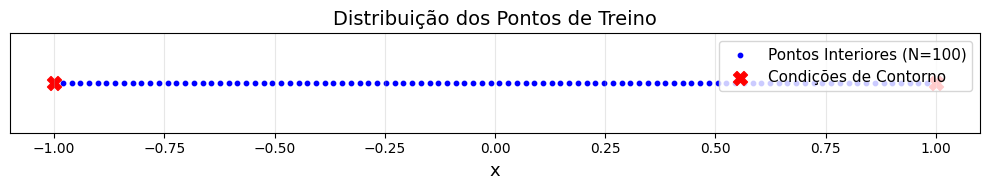

Pontos interiores: 100
Pontos de contorno: 2
x_interior shape: torch.Size([100, 1])
x_bc shape: torch.Size([2, 1])


In [5]:
# ============================================================
# 5. Conjunto de Dados de Treino
# ============================================================

# Número de pontos
N_interior = 100   # Pontos de colocação no interior do domínio
N_bc = 2           # Pontos de contorno (x=-1 e x=1)

# --- Pontos interiores ---
# Distribuídos uniformemente em (-1, 1), excluindo os extremos
x_interior = torch.linspace(-1, 1, N_interior + 2)[1:-1].reshape(-1, 1).to(device)
x_interior.requires_grad = True  # ESSENCIAL para calcular derivadas com autograd

# --- Pontos de contorno ---
x_bc = torch.tensor([[-1.0], [1.0]], dtype=torch.float32).to(device)
u_bc = torch.tensor([[0.0], [0.0]], dtype=torch.float32).to(device)  # u(-1)=0, u(1)=0

# Visualizar a distribuição dos pontos
plt.figure(figsize=(10, 2))
plt.scatter(x_interior.detach().cpu().numpy(), np.zeros(N_interior), 
            c='blue', s=10, label=f'Pontos Interiores (N={N_interior})')
plt.scatter(x_bc.detach().cpu().numpy(), np.zeros(N_bc), 
            c='red', s=100, marker='X', label='Condições de Contorno')
plt.xlabel('x', fontsize=13)
plt.title('Distribuição dos Pontos de Treino', fontsize=14)
plt.legend(fontsize=11)
plt.yticks([])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Pontos interiores: {N_interior}")
print(f"Pontos de contorno: {N_bc}")
print(f"x_interior shape: {x_interior.shape}")
print(f"x_bc shape: {x_bc.shape}")


## 6. Treinamento do Modelo

Treinamos a PINN usando o otimizador **Adam** com uma taxa de aprendizado de $10^{-3}$.

O treinamento em duas fases:
1. **Adam (primeiras iterações):** convergência rápida, bom para sair de regiões ruins do espaço de parâmetros
2. **L-BFGS (refinamento):** otimizador quasi-Newton de segunda ordem, converge com alta precisão

A cada iteração, calculamos a perda total e atualizamos os pesos da rede.


In [6]:
# ============================================================
# 6. Treinamento — Problema 1
# ============================================================

# Hiperparâmetros de treinamento
epochs_adam = 5000       # Épocas com Adam
lr_adam = 1e-3           # Taxa de aprendizado do Adam
lambda_bc = 20.0         # Peso das condições de contorno

# Reiniciar o modelo
model_1 = PINN(hidden_size=32, num_hidden_layers=3).to(device)

# Otimizador Adam
optimizer_adam = torch.optim.Adam(model_1.parameters(), lr=lr_adam)

# Scheduler para reduzir a taxa de aprendizado
scheduler = torch.optim.lr_scheduler.StepLR(optimizer_adam, step_size=2000, gamma=0.5)

# Listas para armazenar o histórico de perda
history_loss_total = []
history_loss_pde = []
history_loss_bc = []

print("=" * 60)
print("FASE 1: Treinamento com Adam")
print("=" * 60)

for epoch in range(epochs_adam):
    optimizer_adam.zero_grad()  # Zerar gradientes
    
    # Calcular perda total
    loss, l_pde, l_bc = loss_total_prob1(model_1, x_interior, x_bc, u_bc, lambda_bc)
    
    # Backpropagation
    loss.backward()
    
    # Atualizar pesos
    optimizer_adam.step()
    scheduler.step()
    
    # Armazenar histórico
    history_loss_total.append(loss.item())
    history_loss_pde.append(l_pde.item())
    history_loss_bc.append(l_bc.item())
    
    # Imprimir progresso
    if (epoch + 1) % 1000 == 0:
        print(f"Época {epoch+1:5d}/{epochs_adam} | "
              f"Loss Total: {loss.item():.6e} | "
              f"Loss PDE: {l_pde.item():.6e} | "
              f"Loss BC: {l_bc.item():.6e}")

print("\nTreinamento com Adam concluído!")


FASE 1: Treinamento com Adam


c:\Users\Guilherme\Documents\GitHub\ppgmc-doutorado\redes-neurais\venv\lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Época  1000/5000 | Loss Total: 2.017130e-03 | Loss PDE: 1.082660e-03 | Loss BC: 4.672351e-05
Época  2000/5000 | Loss Total: 6.274791e-04 | Loss PDE: 5.955773e-04 | Loss BC: 1.595087e-06
Época  3000/5000 | Loss Total: 4.406673e-04 | Loss PDE: 4.406648e-04 | Loss BC: 1.250389e-10
Época  4000/5000 | Loss Total: 2.849804e-04 | Loss PDE: 2.813853e-04 | Loss BC: 1.797525e-07
Época  5000/5000 | Loss Total: 2.136364e-04 | Loss PDE: 2.136354e-04 | Loss BC: 5.211354e-11

Treinamento com Adam concluído!


In [7]:
# ============================================================
# FASE 2: Refinamento com L-BFGS
# ============================================================

print("=" * 60)
print("FASE 2: Refinamento com L-BFGS")
print("=" * 60)

# L-BFGS requer uma closure (função que recalcula a perda)
optimizer_lbfgs = torch.optim.LBFGS(
    model_1.parameters(),
    lr=1.0,
    max_iter=50,
    max_eval=50,
    tolerance_grad=1e-9,
    tolerance_change=1e-12,
    history_size=50,
    line_search_fn='strong_wolfe'
)

lbfgs_iter = [0]

def closure():
    optimizer_lbfgs.zero_grad()
    loss, l_pde, l_bc = loss_total_prob1(model_1, x_interior, x_bc, u_bc, lambda_bc)
    loss.backward()
    
    lbfgs_iter[0] += 1
    if lbfgs_iter[0] % 10 == 0:
        print(f"  L-BFGS iter {lbfgs_iter[0]:4d} | Loss: {loss.item():.6e}")
    
    history_loss_total.append(loss.item())
    history_loss_pde.append(l_pde.item())
    history_loss_bc.append(l_bc.item())
    
    return loss

# Executar L-BFGS (várias vezes para melhor convergência)
for i in range(5):
    optimizer_lbfgs.step(closure)

print(f"\nRefinamento L-BFGS concluído! Total de iterações: {lbfgs_iter[0]}")
print(f"Perda final: {history_loss_total[-1]:.6e}")


FASE 2: Refinamento com L-BFGS
  L-BFGS iter   10 | Loss: 1.979795e-04
  L-BFGS iter   20 | Loss: 1.668211e-04
  L-BFGS iter   30 | Loss: 1.383744e-04
  L-BFGS iter   40 | Loss: 1.223218e-04
  L-BFGS iter   50 | Loss: 1.175262e-04
  L-BFGS iter   60 | Loss: 9.543782e-05
  L-BFGS iter   70 | Loss: 6.413268e-05
  L-BFGS iter   80 | Loss: 2.682371e-05
  L-BFGS iter   90 | Loss: 2.147034e-05
  L-BFGS iter  100 | Loss: 2.112241e-05
  L-BFGS iter  110 | Loss: 2.074617e-05
  L-BFGS iter  120 | Loss: 1.887819e-05
  L-BFGS iter  130 | Loss: 1.402301e-05
  L-BFGS iter  140 | Loss: 1.009720e-05
  L-BFGS iter  150 | Loss: 9.982256e-06
  L-BFGS iter  160 | Loss: 8.683952e-06
  L-BFGS iter  170 | Loss: 7.774552e-06
  L-BFGS iter  180 | Loss: 7.380976e-06
  L-BFGS iter  190 | Loss: 7.347122e-06
  L-BFGS iter  200 | Loss: 6.914177e-06
  L-BFGS iter  210 | Loss: 5.536393e-06
  L-BFGS iter  220 | Loss: 4.166898e-06
  L-BFGS iter  230 | Loss: 3.166695e-06
  L-BFGS iter  240 | Loss: 2.564869e-06
  L-BFGS 

## 7. Análise da Convergência

Visualizamos a evolução da função de perda ao longo do treinamento. Em escala logarítmica, podemos observar a taxa de convergência e identificar se o modelo convergiu adequadamente.


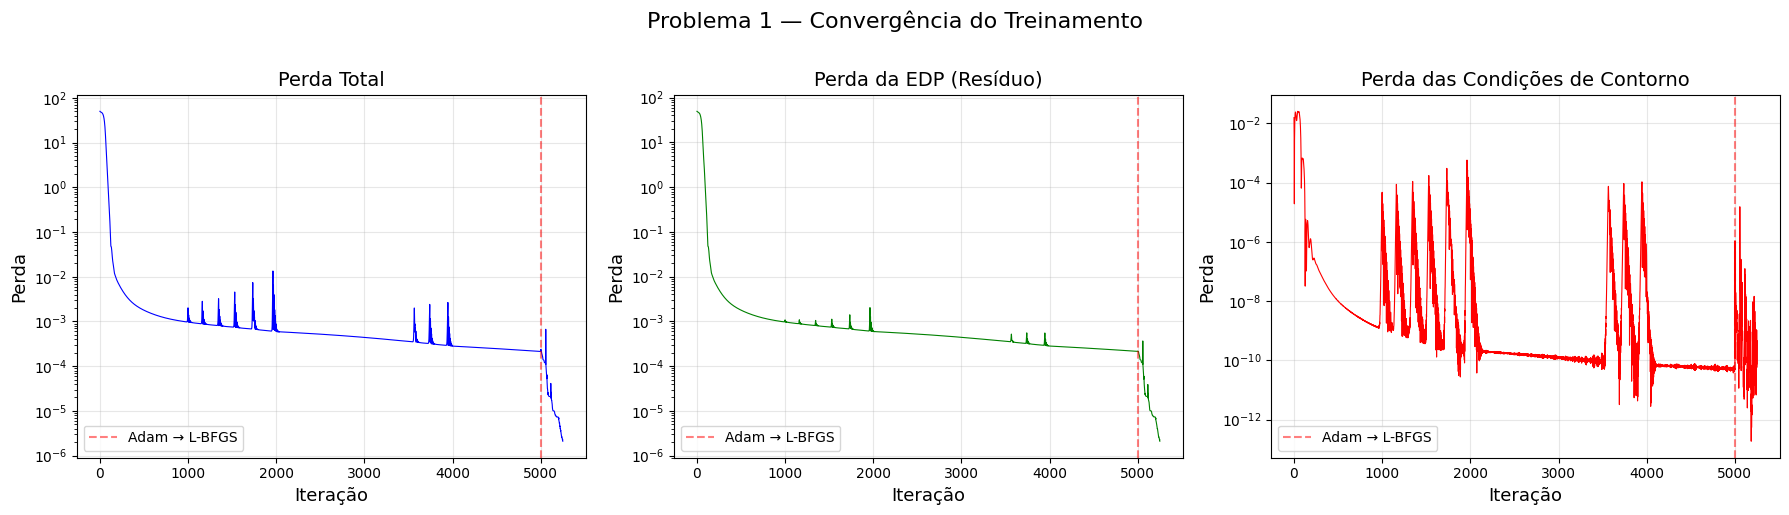

In [8]:
# ============================================================
# 7. Curva de Convergência
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Perda Total
axes[0].semilogy(history_loss_total, 'b-', linewidth=0.8)
axes[0].set_xlabel('Iteração', fontsize=13)
axes[0].set_ylabel('Perda', fontsize=13)
axes[0].set_title('Perda Total', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=epochs_adam, color='r', linestyle='--', alpha=0.5, label='Adam → L-BFGS')
axes[0].legend()

# Perda PDE
axes[1].semilogy(history_loss_pde, 'g-', linewidth=0.8)
axes[1].set_xlabel('Iteração', fontsize=13)
axes[1].set_ylabel('Perda', fontsize=13)
axes[1].set_title('Perda da EDP (Resíduo)', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=epochs_adam, color='r', linestyle='--', alpha=0.5, label='Adam → L-BFGS')
axes[1].legend()

# Perda BC
axes[2].semilogy(history_loss_bc, 'r-', linewidth=0.8)
axes[2].set_xlabel('Iteração', fontsize=13)
axes[2].set_ylabel('Perda', fontsize=13)
axes[2].set_title('Perda das Condições de Contorno', fontsize=14)
axes[2].grid(True, alpha=0.3)
axes[2].axvline(x=epochs_adam, color='r', linestyle='--', alpha=0.5, label='Adam → L-BFGS')
axes[2].legend()

plt.suptitle('Problema 1 — Convergência do Treinamento', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


## 8. Resultados — Comparação com Solução Analítica

Agora usamos o modelo treinado para gerar a solução em todo o domínio e comparamos com a solução analítica exata.


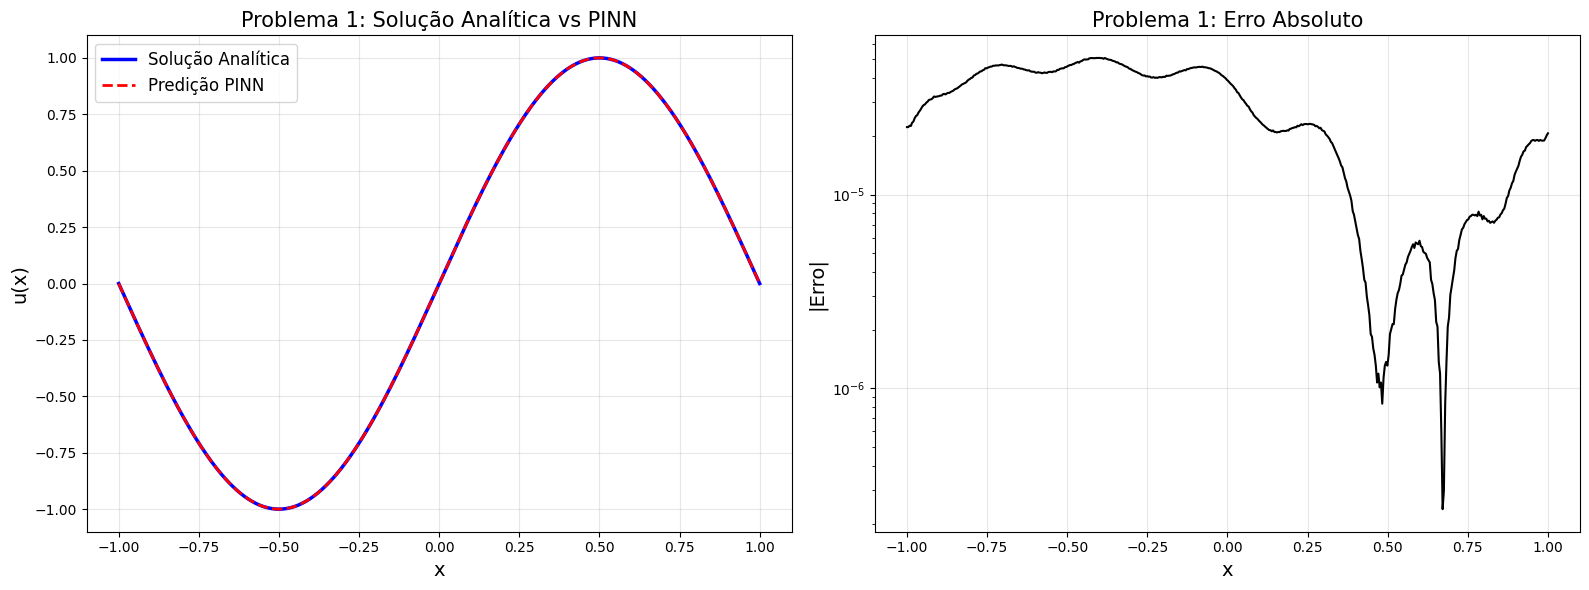

Erro máximo:  5.072355e-05
Erro médio:   2.766716e-05
Erro L2 rel:  4.559877e-05


In [9]:
# ============================================================
# 8. Geração da Solução e Comparação — Problema 1
# ============================================================

# Pontos de teste (mais densos que os de treino)
x_test = torch.linspace(-1, 1, 500).reshape(-1, 1).to(device)

# Predição do modelo (modo avaliação)
model_1.eval()
with torch.no_grad():
    u_pred_1 = model_1(x_test).cpu().numpy()

# Solução analítica nos mesmos pontos
x_test_np = x_test.cpu().numpy().flatten()
u_exact_1 = np.sin(np.pi * x_test_np)

# Erro absoluto
erro_1 = np.abs(u_pred_1.flatten() - u_exact_1)

# --- Plotar ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Solução
axes[0].plot(x_test_np, u_exact_1, 'b-', linewidth=2.5, label='Solução Analítica')
axes[0].plot(x_test_np, u_pred_1, 'r--', linewidth=2, label='Predição PINN')
axes[0].set_xlabel('x', fontsize=14)
axes[0].set_ylabel('u(x)', fontsize=14)
axes[0].set_title('Problema 1: Solução Analítica vs PINN', fontsize=15)
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Erro
axes[1].semilogy(x_test_np, erro_1, 'k-', linewidth=1.5)
axes[1].set_xlabel('x', fontsize=14)
axes[1].set_ylabel('|Erro|', fontsize=14)
axes[1].set_title('Problema 1: Erro Absoluto', fontsize=15)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Métricas de erro
print(f"Erro máximo:  {np.max(erro_1):.6e}")
print(f"Erro médio:   {np.mean(erro_1):.6e}")
print(f"Erro L2 rel:  {np.linalg.norm(u_pred_1.flatten() - u_exact_1) / np.linalg.norm(u_exact_1):.6e}")


---

# PARTE 2 — Problema Modificado

$$\frac{d^2u}{dx^2} = \pi^2 \cos(\pi x), \quad u(-1) = 0, \quad u(1) = 0$$

## 9. Solução Analítica — Problema 2

Resolvendo a EDO:

$$u''(x) = \pi^2 \cos(\pi x)$$

Integrando uma vez:

$$u'(x) = \pi \sin(\pi x) + C_1$$

Integrando novamente:

$$u(x) = -\cos(\pi x) + C_1 x + C_2$$

Aplicando as condições de contorno:
- $u(-1) = -\cos(-\pi) + C_1(-1) + C_2 = -(-1) - C_1 + C_2 = 1 - C_1 + C_2 = 0$
- $u(1) = -\cos(\pi) + C_1(1) + C_2 = -(-1) + C_1 + C_2 = 1 + C_1 + C_2 = 0$

Do sistema:
- $1 - C_1 + C_2 = 0$
- $1 + C_1 + C_2 = 0$

Somando: $2 + 2C_2 = 0 \Rightarrow C_2 = -1$  
Subtraindo: $-2C_1 = 0 \Rightarrow C_1 = 0$

**Solução analítica:** $u(x) = -\cos(\pi x) - 1$

**Verificação:** $u(-1) = -\cos(-\pi) - 1 = 1 - 1 = 0$ ✓  
$u(1) = -\cos(\pi) - 1 = 1 - 1 = 0$ ✓


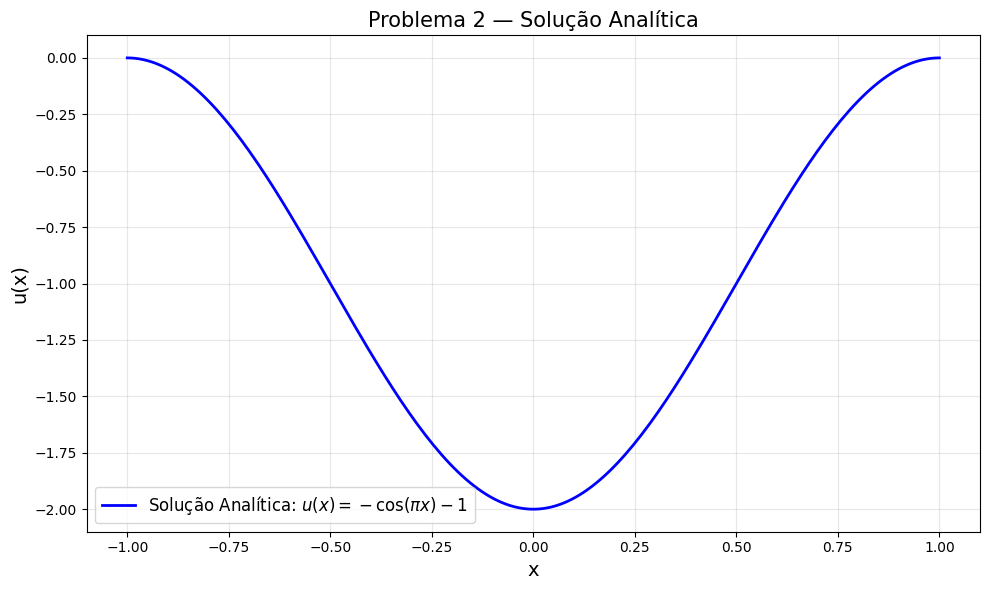

In [10]:
# ============================================================
# 9. Solução Analítica — Problema 2
# ============================================================

u_analitico_2 = -np.cos(np.pi * x_analitico) - 1.0

plt.figure(figsize=(10, 6))
plt.plot(x_analitico, u_analitico_2, 'b-', linewidth=2, 
         label='Solução Analítica: $u(x) = -\cos(\pi x) - 1$')
plt.xlabel('x', fontsize=14)
plt.ylabel('u(x)', fontsize=14)
plt.title('Problema 2 — Solução Analítica', fontsize=15)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 10. Nova Função de Perda e Treinamento — Problema 2

A única mudança em relação ao Problema 1 é a **função fonte** $f(x)$:

- **Problema 1:** $f(x) = -\pi^2 \sin(\pi x)$
- **Problema 2:** $f(x) = \pi^2 \cos(\pi x)$

A arquitetura da rede e o procedimento de treinamento permanecem os mesmos.


In [11]:
# ============================================================
# 10. Função de Perda da EDP — Problema 2
# ============================================================

def loss_pde_prob2(model, x_interior):
    """
    Perda do resíduo da EDP para o Problema 2.
    
    Resíduo: u_xx - f(x) = u_xx - π² cos(πx)
    """
    u, u_xx = compute_derivatives(model, x_interior)
    
    # f(x) = π² cos(πx)  — note a mudança aqui!
    f_x = np.pi**2 * torch.cos(np.pi * x_interior)
    
    # Resíduo
    residuo = u_xx - f_x
    
    return torch.mean(residuo**2)


def loss_total_prob2(model, x_interior, x_bc, u_bc, lambda_bc=10.0):
    """Perda total para o Problema 2."""
    l_pde = loss_pde_prob2(model, x_interior)
    l_bc = loss_bc(model, x_bc, u_bc)
    return l_pde + lambda_bc * l_bc, l_pde, l_bc

print("Função de perda do Problema 2 definida!")


Função de perda do Problema 2 definida!


In [12]:
# ============================================================
# Treinamento — Problema 2 (Adam)
# ============================================================

# Nova instância do modelo (pesos reinicializados)
model_2 = PINN(hidden_size=32, num_hidden_layers=3).to(device)

# Reconstruir pontos interiores (com requires_grad)
x_interior_2 = torch.linspace(-1, 1, N_interior + 2)[1:-1].reshape(-1, 1).to(device)
x_interior_2.requires_grad = True

optimizer_adam_2 = torch.optim.Adam(model_2.parameters(), lr=lr_adam)
scheduler_2 = torch.optim.lr_scheduler.StepLR(optimizer_adam_2, step_size=2000, gamma=0.5)

history2_total = []
history2_pde = []
history2_bc = []

print("=" * 60)
print("PROBLEMA 2 — FASE 1: Treinamento com Adam")
print("=" * 60)

for epoch in range(epochs_adam):
    optimizer_adam_2.zero_grad()
    
    loss, l_pde, l_bc = loss_total_prob2(model_2, x_interior_2, x_bc, u_bc, lambda_bc)
    loss.backward()
    optimizer_adam_2.step()
    scheduler_2.step()
    
    history2_total.append(loss.item())
    history2_pde.append(l_pde.item())
    history2_bc.append(l_bc.item())
    
    if (epoch + 1) % 1000 == 0:
        print(f"Época {epoch+1:5d}/{epochs_adam} | "
              f"Loss Total: {loss.item():.6e} | "
              f"Loss PDE: {l_pde.item():.6e} | "
              f"Loss BC: {l_bc.item():.6e}")

print("\nTreinamento Adam concluído!")


PROBLEMA 2 — FASE 1: Treinamento com Adam
Época  1000/5000 | Loss Total: 7.572256e-04 | Loss PDE: 7.570738e-04 | Loss BC: 7.588183e-09
Época  2000/5000 | Loss Total: 1.116718e-04 | Loss PDE: 1.116669e-04 | Loss BC: 2.422493e-10
Época  3000/5000 | Loss Total: 7.925391e-05 | Loss PDE: 7.925285e-05 | Loss BC: 5.310596e-11
Época  4000/5000 | Loss Total: 5.860873e-05 | Loss PDE: 5.860809e-05 | Loss BC: 3.175504e-11
Época  5000/5000 | Loss Total: 4.904066e-05 | Loss PDE: 4.904026e-05 | Loss BC: 2.004175e-11

Treinamento Adam concluído!


In [13]:
# ============================================================
# Treinamento — Problema 2 (L-BFGS)
# ============================================================

print("=" * 60)
print("PROBLEMA 2 — FASE 2: Refinamento com L-BFGS")
print("=" * 60)

optimizer_lbfgs_2 = torch.optim.LBFGS(
    model_2.parameters(),
    lr=1.0,
    max_iter=50,
    max_eval=50,
    tolerance_grad=1e-9,
    tolerance_change=1e-12,
    history_size=50,
    line_search_fn='strong_wolfe'
)

lbfgs_iter_2 = [0]

def closure_2():
    optimizer_lbfgs_2.zero_grad()
    loss, l_pde, l_bc = loss_total_prob2(model_2, x_interior_2, x_bc, u_bc, lambda_bc)
    loss.backward()
    
    lbfgs_iter_2[0] += 1
    if lbfgs_iter_2[0] % 10 == 0:
        print(f"  L-BFGS iter {lbfgs_iter_2[0]:4d} | Loss: {loss.item():.6e}")
    
    history2_total.append(loss.item())
    history2_pde.append(l_pde.item())
    history2_bc.append(l_bc.item())
    
    return loss

for i in range(5):
    optimizer_lbfgs_2.step(closure_2)

print(f"\nRefinamento L-BFGS concluído! Iterações: {lbfgs_iter_2[0]}")
print(f"Perda final: {history2_total[-1]:.6e}")


PROBLEMA 2 — FASE 2: Refinamento com L-BFGS
  L-BFGS iter   10 | Loss: 4.816601e-05
  L-BFGS iter   20 | Loss: 4.075937e-05
  L-BFGS iter   30 | Loss: 2.986707e-05
  L-BFGS iter   40 | Loss: 2.733967e-05
  L-BFGS iter   50 | Loss: 2.095852e-05
  L-BFGS iter   60 | Loss: 1.937552e-05
  L-BFGS iter   70 | Loss: 1.552898e-05
  L-BFGS iter   80 | Loss: 1.426959e-05
  L-BFGS iter   90 | Loss: 1.404238e-05
  L-BFGS iter  100 | Loss: 6.836434e-06
  L-BFGS iter  110 | Loss: 4.642759e-06
  L-BFGS iter  120 | Loss: 3.926209e-06
  L-BFGS iter  130 | Loss: 2.979654e-06
  L-BFGS iter  140 | Loss: 2.294488e-06
  L-BFGS iter  150 | Loss: 2.170250e-06
  L-BFGS iter  160 | Loss: 2.128590e-06
  L-BFGS iter  170 | Loss: 2.084265e-06
  L-BFGS iter  180 | Loss: 1.567454e-06
  L-BFGS iter  190 | Loss: 1.564490e-06
  L-BFGS iter  200 | Loss: 1.564091e-06

Refinamento L-BFGS concluído! Iterações: 206
Perda final: 1.564091e-06


## 11. Resultados — Problema 2


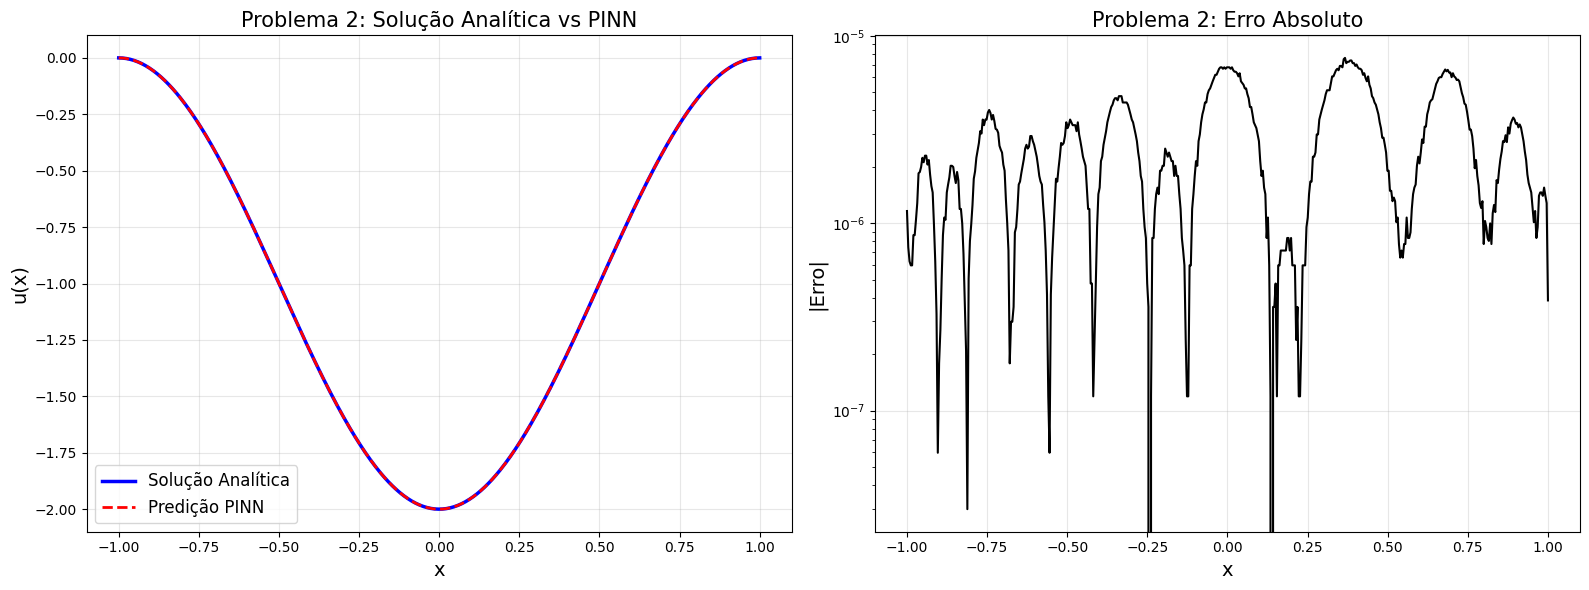

Erro máximo:  7.629395e-06
Erro médio:   2.785176e-06
Erro L2 rel:  2.798607e-06


In [14]:
# ============================================================
# 11. Geração da Solução e Comparação — Problema 2
# ============================================================

model_2.eval()
with torch.no_grad():
    u_pred_2 = model_2(x_test).cpu().numpy()

u_exact_2 = -np.cos(np.pi * x_test_np) - 1.0
erro_2 = np.abs(u_pred_2.flatten() - u_exact_2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(x_test_np, u_exact_2, 'b-', linewidth=2.5, label='Solução Analítica')
axes[0].plot(x_test_np, u_pred_2, 'r--', linewidth=2, label='Predição PINN')
axes[0].set_xlabel('x', fontsize=14)
axes[0].set_ylabel('u(x)', fontsize=14)
axes[0].set_title('Problema 2: Solução Analítica vs PINN', fontsize=15)
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(x_test_np, erro_2, 'k-', linewidth=1.5)
axes[1].set_xlabel('x', fontsize=14)
axes[1].set_ylabel('|Erro|', fontsize=14)
axes[1].set_title('Problema 2: Erro Absoluto', fontsize=15)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Erro máximo:  {np.max(erro_2):.6e}")
print(f"Erro médio:   {np.mean(erro_2):.6e}")
print(f"Erro L2 rel:  {np.linalg.norm(u_pred_2.flatten() - u_exact_2) / np.linalg.norm(u_exact_2):.6e}")


---

## 12. Comparação Final entre os Dois Problemas

Comparamos as soluções dos dois problemas lado a lado, analisando as diferenças em termos de forma da solução, dificuldade de treinamento e precisão.


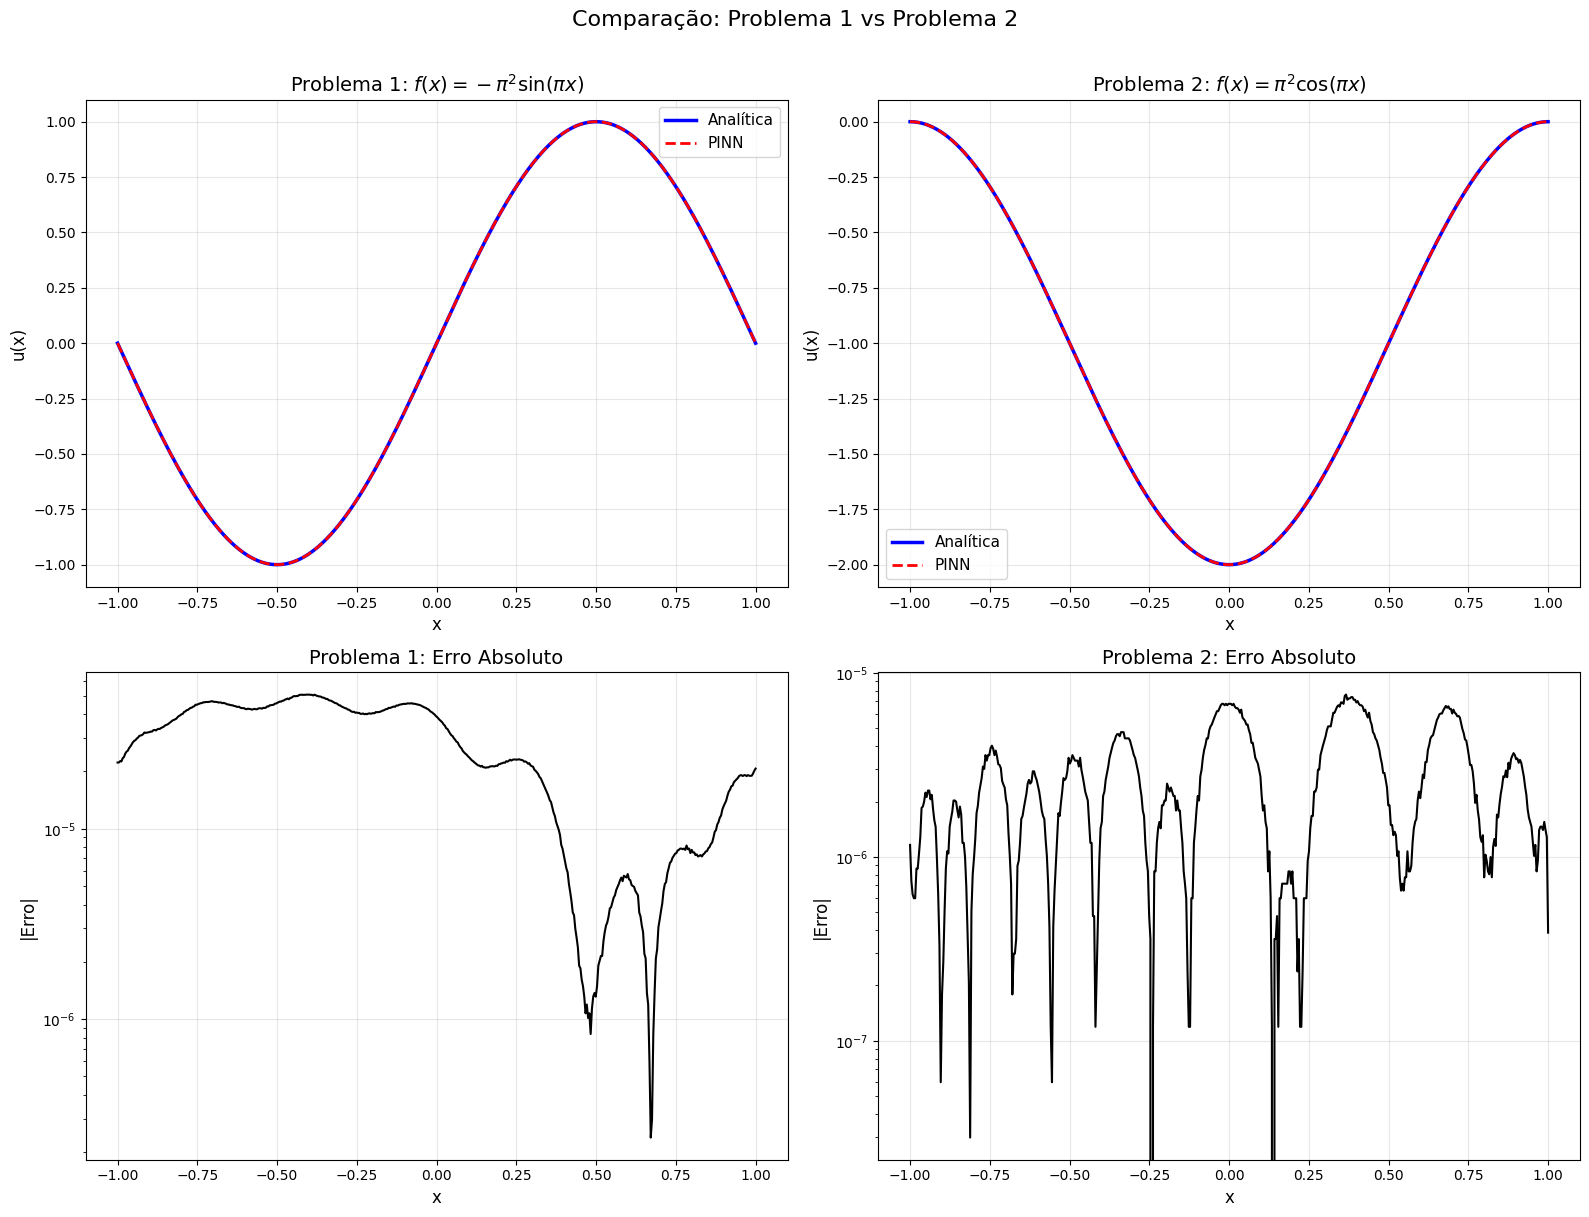

In [15]:
# ============================================================
# 12. Comparação Final
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Soluções ---
# Problema 1
axes[0, 0].plot(x_test_np, u_exact_1, 'b-', linewidth=2.5, label='Analítica')
axes[0, 0].plot(x_test_np, u_pred_1, 'r--', linewidth=2, label='PINN')
axes[0, 0].set_title('Problema 1: $f(x) = -\pi^2 \sin(\pi x)$', fontsize=14)
axes[0, 0].set_xlabel('x', fontsize=12)
axes[0, 0].set_ylabel('u(x)', fontsize=12)
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Problema 2
axes[0, 1].plot(x_test_np, u_exact_2, 'b-', linewidth=2.5, label='Analítica')
axes[0, 1].plot(x_test_np, u_pred_2, 'r--', linewidth=2, label='PINN')
axes[0, 1].set_title('Problema 2: $f(x) = \pi^2 \cos(\pi x)$', fontsize=14)
axes[0, 1].set_xlabel('x', fontsize=12)
axes[0, 1].set_ylabel('u(x)', fontsize=12)
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# --- Erros ---
axes[1, 0].semilogy(x_test_np, erro_1, 'k-', linewidth=1.5)
axes[1, 0].set_title('Problema 1: Erro Absoluto', fontsize=14)
axes[1, 0].set_xlabel('x', fontsize=12)
axes[1, 0].set_ylabel('|Erro|', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].semilogy(x_test_np, erro_2, 'k-', linewidth=1.5)
axes[1, 1].set_title('Problema 2: Erro Absoluto', fontsize=14)
axes[1, 1].set_xlabel('x', fontsize=12)
axes[1, 1].set_ylabel('|Erro|', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Comparação: Problema 1 vs Problema 2', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


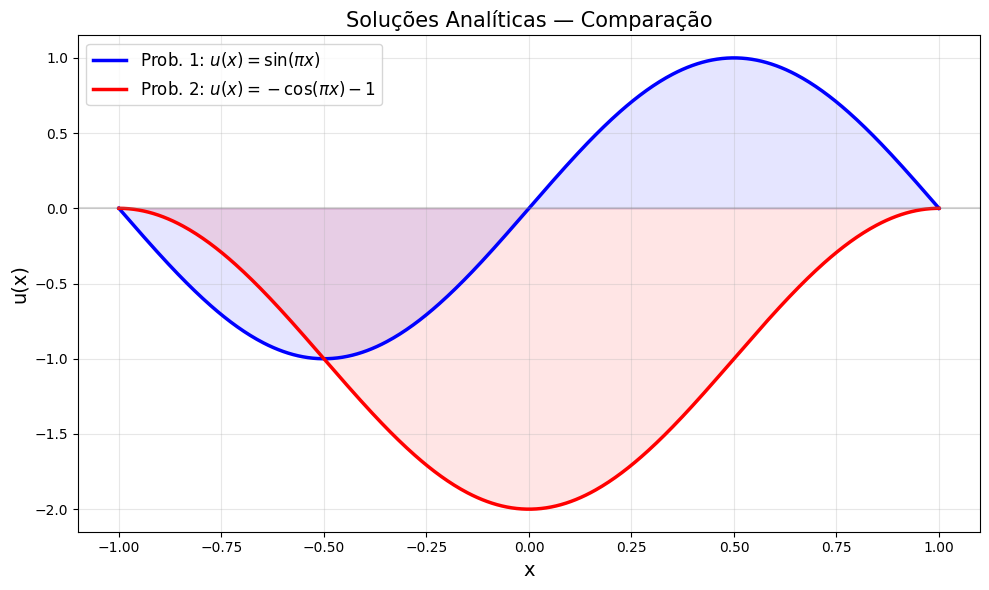

In [16]:
# ============================================================
# Comparação das Soluções Analíticas
# ============================================================

plt.figure(figsize=(10, 6))
plt.plot(x_test_np, u_exact_1, 'b-', linewidth=2.5, label='Prob. 1: $u(x) = \sin(\pi x)$')
plt.plot(x_test_np, u_exact_2, 'r-', linewidth=2.5, label='Prob. 2: $u(x) = -\cos(\pi x) - 1$')
plt.fill_between(x_test_np, u_exact_1, alpha=0.1, color='blue')
plt.fill_between(x_test_np, u_exact_2, alpha=0.1, color='red')
plt.xlabel('x', fontsize=14)
plt.ylabel('u(x)', fontsize=14)
plt.title('Soluções Analíticas — Comparação', fontsize=15)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()


In [17]:
# ============================================================
# Comparação Numérica
# ============================================================

print("=" * 65)
print("           COMPARAÇÃO NUMÉRICA DOS RESULTADOS")
print("=" * 65)
print(f"{'Métrica':<25} {'Problema 1':>18} {'Problema 2':>18}")
print("-" * 65)
print(f"{'Erro máximo':<25} {np.max(erro_1):>18.6e} {np.max(erro_2):>18.6e}")
print(f"{'Erro médio':<25} {np.mean(erro_1):>18.6e} {np.mean(erro_2):>18.6e}")

l2_1 = np.linalg.norm(u_pred_1.flatten() - u_exact_1) / np.linalg.norm(u_exact_1)
l2_2 = np.linalg.norm(u_pred_2.flatten() - u_exact_2) / np.linalg.norm(u_exact_2)
print(f"{'Erro L2 relativo':<25} {l2_1:>18.6e} {l2_2:>18.6e}")

print(f"{'Loss final (treino)':<25} {history_loss_total[-1]:>18.6e} {history2_total[-1]:>18.6e}")
print("=" * 65)


           COMPARAÇÃO NUMÉRICA DOS RESULTADOS
Métrica                           Problema 1         Problema 2
-----------------------------------------------------------------
Erro máximo                     5.072355e-05       7.629395e-06
Erro médio                      2.766716e-05       2.785176e-06
Erro L2 relativo                4.559877e-05       2.798607e-06
Loss final (treino)             2.104409e-06       1.564091e-06


---

## 13. Conclusões

### Resumo dos Resultados

Ambos os problemas de Poisson 1D foram resolvidos com sucesso usando PINNs implementadas em PyTorch.

### Observações sobre os dois problemas:

1. **Problema 1** ($f(x) = -\pi^2 \sin(\pi x)$, solução: $u(x) = \sin(\pi x)$):
   - A solução é uma senóide que se anula naturalmente nos contornos
   - O treinamento tende a convergir bem pois a solução é suave e compatível com a ativação $\tanh$

2. **Problema 2** ($f(x) = \pi^2 \cos(\pi x)$, solução: $u(x) = -\cos(\pi x) - 1$):
   - A solução é sempre não-positiva no domínio $[-1, 1]$, com valor mínimo $-2$ em $x=0$
   - As condições de contorno são satisfeitas pois $-\cos(\pm\pi) - 1 = 1 - 1 = 0$

### Vantagens das PINNs:
- **Mesh-free:** não requer uma malha de elementos finitos
- **Flexibilidade:** facilmente adaptável para diferentes EDPs
- **Diferenciação automática:** as derivadas são calculadas exatamente pelo autograd

### Limitações:
- O treinamento pode ser lento para problemas complexos
- A convergência depende fortemente da arquitetura e dos hiperparâmetros
- Para problemas de alta dimensão, o custo computacional pode ser significativo

### Referências:
- Raissi, M., Perdikaris, P., & Karniadakis, G. E. (2019). Physics-informed neural networks.
- Tutorial base: [PINNs - Poisson 1D Dirichlet](https://github.com/praksharma/Learning-Python-Physics-Informed-Machine-Learning-PINNs-DeepONets/blob/main/PINNs/3_Poisson1D_Dirichlet.ipynb)
